In [ ]:
#Unet
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import re

import os
from natsort import natsorted

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

import scipy.fftpack
from centerline.src.make_skeleton import make_skeleton

### Visualize centerlines with raw mask, segmented mask

The ouput of the code below looked like this. But it has to be improved:


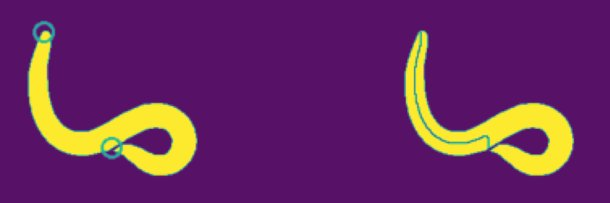

In [ ]:
#I should rewrite-rearrange this more modular!

import os
import glob

#define number of splines
num_splines=100

#define expected skeleton minimum length
skel_min_length=300

#Compile regular expressions into pattern objects 
regex = re.compile(r'\d+')

main_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/'

for folder in natsorted(os.listdir(main_path)):
    if '.DS' in folder: continue
    print(folder)
    h5_path=glob.glob(os.path.join(main_path,folder)+'/*.h5')
    #print(os.path.join(main_path,folder))
    print(h5_path)
    print(h5_path[0])
    
    df=pd.read_hdf(h5_path[0])
    
    img_path=os.path.join(main_path,folder,'binary/')
    #print(img_path)
    
    output_path=os.path.join(main_path,folder,'centerlines2/')
    os.makedirs(output_path,exist_ok=True)
    #print(output_path)
    img_list=natsorted(os.listdir(img_path))

    scorer=df.columns.get_level_values(0)[0]
    head_x=df[scorer]['Head']['x'].values
    head_y=df[scorer]['Head']['y'].values
    tail_x=df[scorer]['Tail']['x'].values
    tail_y=df[scorer]['Tail']['y'].values
    
    #create writer object
    csvfileX=open(output_path+'spline_X_coords.csv','w', newline='')
    csvfileX_writer=csv.writer(csvfileX)
    csvfileY=open(output_path+'spline_Y_coords.csv','w', newline='')
    csvfileY_writer=csv.writer(csvfileY)

    csvfilename=open(output_path+'filename.csv','w', newline='')
    csvfilename_writer=csv.writer(csvfilename)
    #set counters for failed centerlines
    c1=0
    c2=0



    for filename in img_list:
        if 'img' in filename:

            #print(filename)
            
            #this int() might be not a good idea, check!
            i=int(regex.search(filename).group(0))
            #print(i)
            start_point=(int(head_y[i]), int(head_x[i]))
            end_point = (int(tail_y[i]), int(tail_x[i]))
            #print(start_point)
            #print(end_point)

            img=tiff.imread(os.path.join(img_path,filename))

            annotated_img=img.copy()
            cv2.circle(annotated_img,(int(head_x[i]), int(head_y[i])),10, (150,150,150), 2)
            cv2.circle(annotated_img,(int(tail_x[i]), int(tail_y[i])),10, (150,150,150), 2)

    #         plt.figure(figsize=(10,10), dpi=150)
    #         plt.subplot(1,2,1)
    #         plt.imshow(annotated_img)

            u, skel_coords, spline_coords, K=make_skeleton(start_point, end_point,num_splines, img)
            #print(skel_coords[0].shape)

            #try to unpack the skel_coords as an array of int (will fail if skel_coords contains NaN)
            try: coords=np.asarray(list(zip(*skel_coords)), dtype=int)# the dtype=int makes sures no NaN can be passed, which will cause trouble when indexing
            except:
                c1=c1+1
                #print('head and tail were too close, no centerline could be created', c1)

            else:
                #counter for short skel coords
                if len(skel_coords[0])<=skel_min_length:
                    c2=c2+1
                    #print('short centerline', c2)

                #draw zeros on the skel_img where the are coordinates
                skel_img=img.copy()
                for idx,coords in enumerate(coords):
                    skel_img[coords[0],coords[1]]=0

                #save coordinates of the good centerlines
                if len(skel_coords[0])>skel_min_length:
                    print(i)
                    x,y=np.asarray(spline_coords)
                    csvfileX_writer.writerow(x)
                    csvfileY_writer.writerow(y)
                    #would [filename] alone work? filename without[] writes every letter in a different cell
                    csvfilename_writer.writerow([os.path.join('labeled-data',folder,filename)])#(['filename:',filename])
                #plotting
                ##if i!=0: continue
                print(filename)
                #plt.figure(figsize=(10,10), dpi=100)
                
                
                fig, axes = plt.subplots(nrows=1, ncols=2, dpi=200)
                axes[0].imshow(annotated_img)
                axes[1].imshow(skel_img)
                #axes[0].set_aspect('equal')
                for ax in axes:
                    ax.set_xlim(100, 500)
                    ax.set_ylim(100, 500)
                    ax.axis('off')
                #axes[1].axis('off')
                #axes[1].set_aspect('equal')
                fig.subplots_adjust(wspace=0, hspace=0)
                plt.show()
                #break
                #check if the skel_coords are too short
    csvfileX.close()
    csvfileY.close()
    csvfilename.close()
    print('Failed centerlines: ', c1,'\nVery short centerlines:', c2, '\nGood centerlines: ', len(img_list)-c1-c2,'\nTotal centerlines: ', len(img_list))



### Trying to get centerline output coordinates from dlc to fit into spline

In [ ]:
costs=cv2.distanceTransform(img, cv2.DIST_L2,3)
cv2.normalize(costs, costs, 0, 255, cv2.NORM_MINMAX)
costs=costs.max()-costs


#to increase the value a lot of the pixels outside the worm contour (np.inf will not work! sometimes head and tail outside work contour)
costs=np.where(costs>254.9, 255*100, costs)
#actual skeleton based on shortest_path of skimage
#actual skeleton based on route through array from skimage

start_point, end_point =(326,300),(268,237)
path, cost = skimage.graph.route_through_array(costs, start=start_point, end=end_point, fully_connected=False)
pts=np.asarray(path, dtype=np.int)

### Plot Kymograms

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Load csv files

In [ ]:
path_before='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_before_unet/2020-07-01_18-36-25_control_worm6_spline_K.csv'
df_before=pd.read_csv(path_before, header=None)

In [ ]:
plt.figure(figsize=(600,40))
plt.imshow(df_before.T,origin="upper",cmap='seismic',extent=[0,df_before.shape[0],df_before.shape[1],0],aspect=20,vmin=-0.05,vmax=0.05)

In [ ]:
path_after='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_unet/2020-07-01_18-36-25_control_worm6_spline_K.csv'
df_after=pd.read_csv(path_after, header=None)

In [ ]:
plt.figure(figsize=(600,40))
plt.imshow(df_after.T,origin="upper",cmap='seismic',extent=[0,df_after.shape[0],df_after.shape[1],0],aspect=20,vmin=-0.05,vmax=0.05)

In [ ]:
coiled_shapes_dict={'ot1.tif':np.arange(2800,5603),
                    'ot2.tif':np.arange(6676,7300),
                    'ot3.tif':np.arange(18500,21000),
                    'ot4.tif':np.arange(21600,22345),
                    'ot5.tif':np.arange(24300,24900),
                    'ot6.tif':np.arange(27616,28200),
                    'ot7.tif':np.arange(34588,35400),
                    'ot8.tif':np.arange(38980,40000),
                    'ot9.tif':np.arange(47800,48600),
                    'ot10.tif':np.arange(59300,60100),
                    'ot11.tif':np.arange(62150,63340),
                    'ot12.tif':np.arange(93780,94100),
                    'ot13.tif':np.arange(108150,109350),
                    'ot14.tif':np.arange(116500,117200),
                    'ot15.tif':np.arange(163100,163600),
                    'ot16.tif':np.arange(165660,166690),
                    'ot17.tif':np.arange(171200,172400),
                    'ot18.tif':np.arange(172900,173960),
                    'ot19.tif':np.arange(194195,195000)}

### these ones are narrower, including less time before and after reversal


In [ ]:
coiled_shapes_dict={'ot1.tif':np.arange(2800,5603),
                    'ot2.tif':np.arange(6600,7150),
                    'ot3.tif':np.arange(19175,19750),
                    'ot4.tif':np.arange(21670,22345),
                    'ot5.tif':np.arange(24340,24850),
                    'ot6.tif':np.arange(27616,28200),
                    'ot7.tif':np.arange(34588,35400),
                    'ot8.tif':np.arange(38980,40000),
                    'ot9.tif':np.arange(47800,48600),
                    'ot10.tif':np.arange(59300,60100),
                    'ot11.tif':np.arange(62150,63340),
                    'ot12.tif':np.arange(93780,94100),
                    'ot13.tif':np.arange(108150,109350),
                    'ot14.tif':np.arange(116500,117200),
                    'ot15.tif':np.arange(163100,163600),
                    'ot16.tif':np.arange(165660,166690),
                    'ot17.tif':np.arange(171200,172400),
                    'ot18.tif':np.arange(172900,173960),
                    'ot19.tif':np.arange(194195,195000)}

In [ ]:
#plot kymograms of all OT
plt.rcParams.update({'font.size': 7})
fps=167
print ('total,before,after,before_norm,after_norm')

for keys, frames in coiled_shapes_dict.items():
    #print(frames)
    new_df_after=df_after[frames[0]:frames[-1]]
    #print(keys)
    new_df_before=df_before[frames[0]:frames[-1]]
    #compare before and after nans
    total_frames=new_df_before.shape[0]
    print(total_frames,new_df_before.isna().any(axis=1).sum(), new_df_after.isna().any(axis=1).sum(), new_df_before.isna().any(axis=1).sum()/new_df_before.isna().any(axis=1).sum(), new_df_after.isna().any(axis=1).sum()/new_df_before.isna().any(axis=1).sum())

        #plottingg
    fig, axes=plt.subplots(figsize=(10,4),dpi=200, nrows=2)
    fig.subplots_adjust(wspace=0, hspace=1)

    axes[0].imshow(new_df_before.T*-1,origin="upper",cmap='seismic',extent=[0,new_df_before.shape[0]/fps,new_df_before.shape[1],0],aspect=0.02,vmin=-0.05,vmax=0.05)
    axes[0].set_title('Binary worm')
    #axes[0].x_axis('off')
    axes[1].imshow(new_df_after.T*-1,origin="upper",cmap='seismic',extent=[0,new_df_after.shape[0]/fps,new_df_after.shape[1],0],aspect=0.02,vmin=-0.05,vmax=0.05)
    axes[1].set_title('Binary worm with U-Net')

    for ax in axes:
        ax.set_ylabel('Bodypart')
        ax.set_xlabel('Time (s)')
    fig.suptitle(keys, fontsize=9)

### Test with Find Corner for Head and Tail detection

In [ ]:
import tifffile as tiff
import cv2
from scipy.signal import convolve2d

In [ ]:
post_unet_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_new_unet/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff_binary_200th.btf'

pre_unet_filepath='t/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/btf_all_binary2_eroded_binarized/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff.btf'

output_writer_path='/scratch/zimmer/Ulises_temp/head_tail.tif'
skel_writer_path='/scratch/zimmer/Ulises_temp/skel.tif'
raw_writer_path='/scratch/zimmer/Ulises_temp/raw.tif'

#generate a kernel of ones
kernel=np.ones((3,3))
#conver it to kernel of -1
kernel=kernel*-1
#set the center of the kernel to 255
kernel[1,1]=255

#plot the kernel
plt.imshow(kernel)
plt.show()

with tiff.TiffFile(post_unet_filepath, multifile=False) as tif,\
tiff.TiffWriter(output_writer_path, bigtiff=True) as tif_writer,\
tiff.TiffWriter(skel_writer_path, bigtiff=True) as tif_skel_writer,\
tiff.TiffWriter(raw_writer_path, bigtiff=True) as tif_raw_writer:
    for i, page in enumerate(tif.pages[19000:20000]):
        img=page.asarray()
        
        skel=skeletonize(img/255)
        #conver to uint zeros and ones
        skel=np.asarray(skel, dtype="uint8")
        
        #apply the convolution
        mask = convolve2d(skel, kernel, mode='same', fillvalue=1)
        #threshold anything below 254. The pixels that had only one neighbouring pixel have value 254.
        mask[mask<254]=0
        #conver to uint (I dont think it is needed)
        #now mask contains 254 in the edges, 0 everywhere else
        mask=np.asarray(mask, dtype="uint8")
        #bring skeleton to value 255
        skel=np.asarray(skel*255, dtype="uint8")
        
        
        tif_writer.write(mask, contiguous=True)
        tif_skel_writer.write(skel, contiguous=True)
        tif_raw_writer.write(img, contiguous=True)

        
        #plotting
#         fig,axes=plt.subplots(figsize=(10,10), ncols=3, dpi=200)
#         axes[0].imshow(img)
#         axes[1].imshow(skel)
#         axes[2].imshow(mask)
#         #plt.imshow(img)
#         axes[0].set_title(str(i)+' original image')
#         axes[2].set_title(str(i)+' image with detected corners')
        
        
        #if i > 1000: break

In [ ]:
mask.max()

In [ ]:
np.where(mask==254)

In [ ]:
len(r)

In [ ]:
img.shape[0]*img.shape[1]